In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/heart.csv")
df


Mounted at /content/drive


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
df.info()
print(df.isnull().sum())
df.describe()
print()
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

723
0


In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


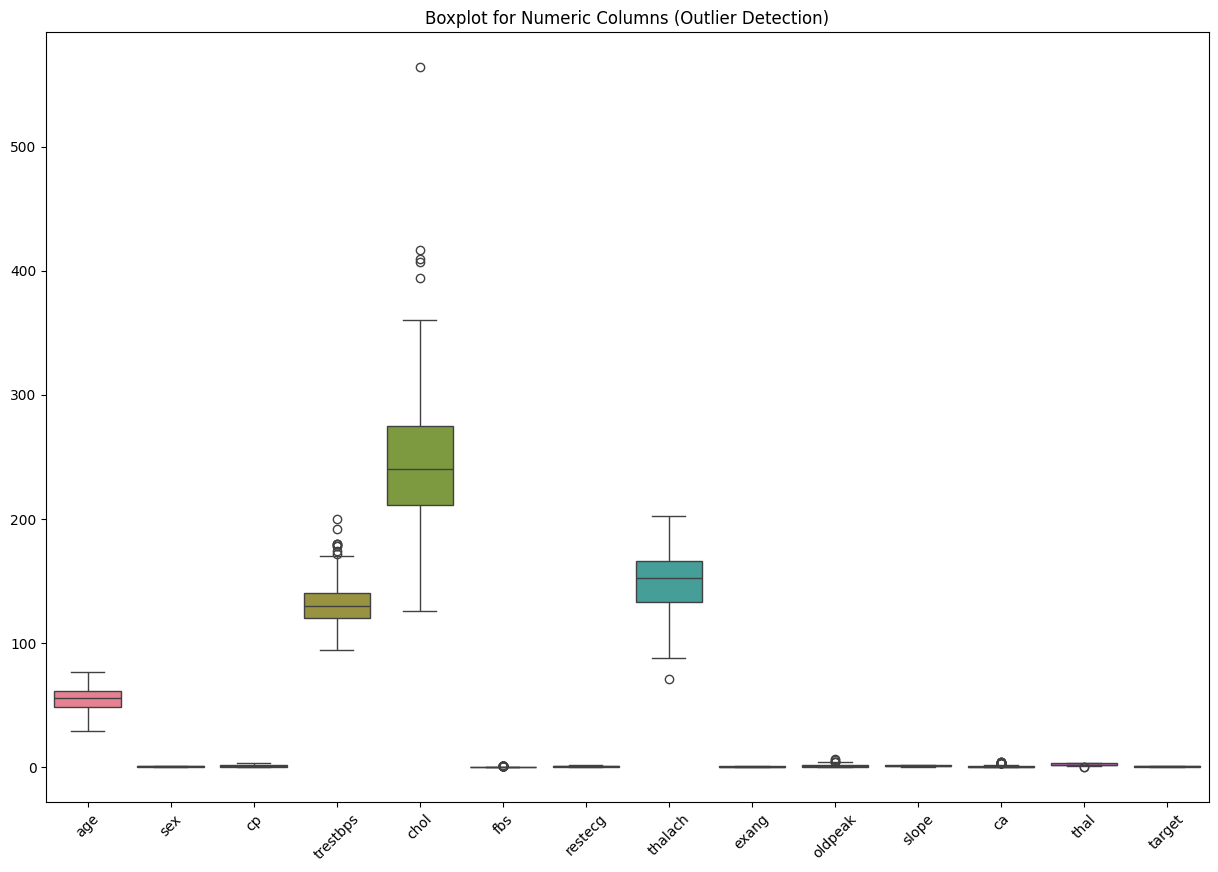

In [ ]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot all numeric columns
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for Numeric Columns (Outlier Detection)")
plt.show()


In [ ]:
# Calculate IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers (clip values)
df_capped = df.copy()
for col in df.columns:
    if df[col].dtype != 'object':  # only for numeric columns
        df_capped[col] = np.where(df[col] < lower_bound[col], lower_bound[col],
                          np.where(df[col] > upper_bound[col], upper_bound[col], df[col]))

print("Before capping:", df.shape)
print("After capping:", df_capped.shape)

Before capping: (302, 14)
After capping: (302, 14)


<Axes: >

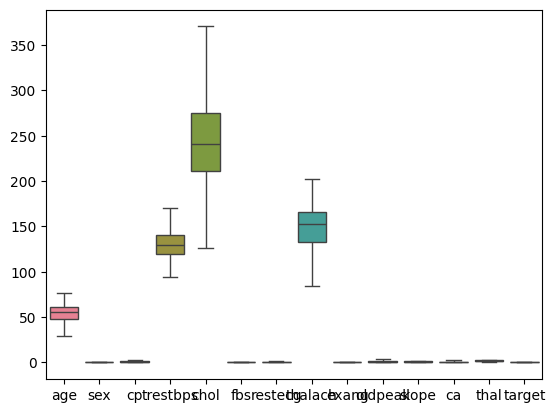

In [ ]:
sns.boxplot(data=df_capped)

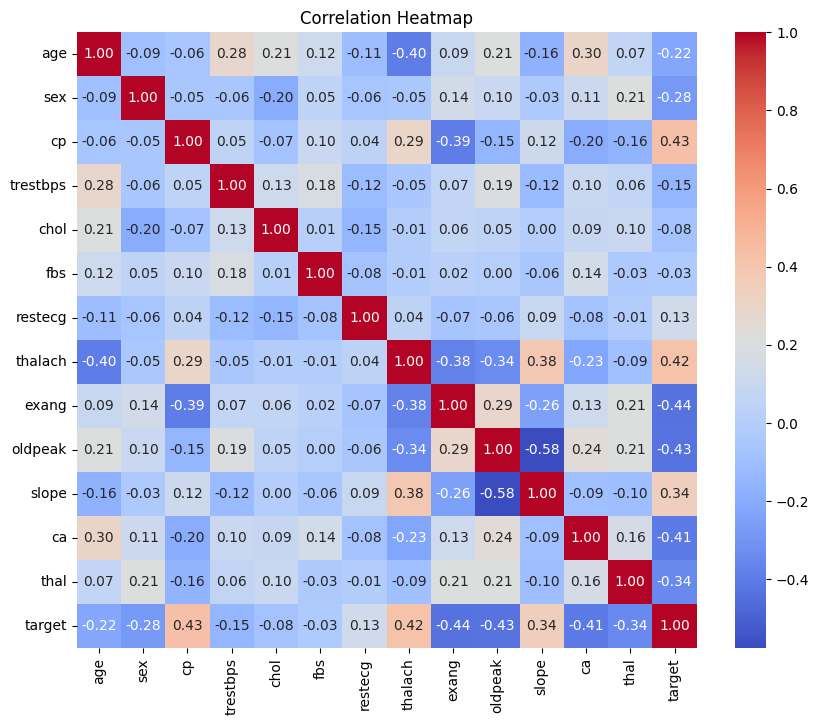

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Separate features and target
x = df_capped.drop('target', axis=1)
y = df_capped['target']

# Scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x) # convert to  array that why i couldnt use iloc while predecting

In [ ]:
# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [ ]:
#  Logistic Regression ---
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
y_pred_lr = log_reg.predict(x_test)

print("Logistic Regression Results ")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results 
Accuracy: 0.8032786885245902
[[24  8]
 [ 4 25]]
              precision    recall  f1-score   support

         0.0       0.86      0.75      0.80        32
         1.0       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)
y_pred_tree = tree.predict(x_test)

print(" Decision Tree Results ")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

 Decision Tree Results 
Accuracy: 0.7049180327868853
[[24  8]
 [10 19]]
              precision    recall  f1-score   support

         0.0       0.71      0.75      0.73        32
         1.0       0.70      0.66      0.68        29

    accuracy                           0.70        61
   macro avg       0.70      0.70      0.70        61
weighted avg       0.70      0.70      0.70        61



In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(" Random Forest Results ")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

 Random Forest Results 
Accuracy: 0.8524590163934426
[[26  6]
 [ 3 26]]
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85        32
         1.0       0.81      0.90      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



In [ ]:
# Save the trained Random Forest model
joblib.dump(rf, 'heart_disease_model.pkl')
print(" Model saved as heart_disease_model.pkl")

 Model saved as heart_disease_model.pkl


In [ ]:
# Load the saved model
model = joblib.load('heart_disease_model.pkl')


files.download('heart_disease_model.pkl')

# Try predicting one sample to check

sample = x_test[0].reshape(1, -1)
prediction = model.predict(sample)
print("Prediction:", prediction)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Prediction: [1.]
